# Are the misread muons and the experimental excess the same events?

The nu-classifier scores every event. At a threshold of 0.8 the simulated muons that the
classifier gets wrong (**group 6**) and the experimental events it accepts (**group 8**) are
the two populations this notebook compares.

The previous study established that group 8 is about twice as large as the muon simulation
predicts, and that it *sits on top of* group 6 in the classifier's own representation. That
argument used the classifier to judge the classifier's failure. This one does not: every
quantity here is measured from the hits, and the comparison is made in a space the network
never sees.

**The question in one line.** Are 6 and 8 the same physical population — so that the excess is
that population being commoner in data than in simulation — or are they different?

**Why it is not obvious.** The two groups are selected by the same network at the same
threshold, which invites the assumption that they must therefore look alike. Under domain
shift that does not follow: a score cut can land on one region of feature space in simulation
and a different region in data. Whether it does is question §2.

## 0. Definitions, and one thing this cannot do

### The eight groups

Every event passing the quality cut (`n_sig_hits ≥ 8`, `n_sig_strings ≥ 3`, the project's
"h8s3") falls into one of eight groups by its class and its classifier score ξ = 0.8. MC events
the model trained on are excluded; so are the two experimental runs with the verified channel
fault.

### "The excess" names a surplus in counts, not a set of events

Group 8 holds 3,044 events. About 1,546 of them are the muon background the simulation
predicts and about 1,498 are surplus — but **no individual event can be assigned to either**,
because nothing distinguishes a misread muon in the data from whatever else may be there.

This governs every figure below. When a plot shows "group 8" it shows both components at once,
so a statement about the surplus alone is an inference about the *mixture*: were the surplus
half a different kind of event, the mixture would betray it as a second component — a
displacement, a second lobe, a broadening relative to group 6. That is the form the argument
takes, and it is weaker than observing the surplus directly. It is also the only form available.

### No absolute normalisation

The muon simulation carries `event_weight` identically 1 and no generated livetime is recorded
anywhere. Every statement here is about **shape and composition**, never about rates. That is
also why the headline statistic is an AUC: it compares distributions and is blind to the fact
that group 6 holds 7,751 events and group 8 holds 3,044.

In [1]:
import sys, warnings
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

HERE = Path("/home/albert/Baikal2025/inference_v2/nu_classifier/analysis/excess_mechanism")
sys.path.insert(0, str(HERE))
warnings.filterwarnings("ignore", category=FutureWarning)

from analysis import (SEED, apply_rules, concentration, fit_tree, novelty,  # noqa: E402
                      part_split, permutation_null)
from features import COLUMNS  # noqa: E402

db = duckdb.connect(str(HERE / "features.duckdb"), read_only=True)
query = lambda sql: db.execute(sql).df()

GROUP_NAME = {1: "nuatm  < 0.8", 2: "nuatm  >= 0.8", 3: "nue2  < 0.8", 4: "nue2  >= 0.8",
              5: "muatm < 0.8", 6: "muatm >= 0.8", 7: "exp   < 0.8", 8: "exp   >= 0.8"}

# Reference categorical palette, CVD-validated, fixed order.
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"

def style(ax):
    ax.set_facecolor(SURFACE); ax.grid(color="#e5e4e0", linewidth=0.8); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color("#c9c8c3")
    ax.tick_params(colors=MUTED, length=0)
    return ax

(HERE / "figures").mkdir(exist_ok=True)
feat = query("SELECT * FROM features")
print(f"{len(feat):,} events, {len(COLUMNS)} features")

628,456 events, 52 features


In [2]:
counts = (feat.groupby("group_id")
              .agg(sampled=("event_fk", "size"), parts=("part_key", "nunique"))
              .reset_index())
counts["population"] = counts.group_id.map(GROUP_NAME)
# the true group sizes, from the prediction DBs -- `sampled` is what was read for features
TRUE_N = {1: 5_162, 2: 525_904, 3: 12_499, 4: 1_360_695,
          5: 23_159_967, 6: 7_751, 7: 3_177_637, 8: 3_044}
counts["in_full_sample"] = counts.group_id.map(TRUE_N)
counts["exhaustive"] = counts.group_id.isin([1, 3, 6, 8])
display(counts[["group_id", "population", "in_full_sample", "sampled", "parts", "exhaustive"]])
print("Groups 1, 3, 6 and 8 are taken whole; 2, 4, 5 and 7 are quota samples, drawn "
      "deterministically by ORDER BY hash(event_fk) and unbiased within class.")
print("That matters for section 4.1, whose control compares against groups 5 and 7: a sample "
      "biased within its class would move the control. Measured rather than assumed -- group 5 "
      "events from the parts this study reads agree with those from the parts it does not, to "
      "the third digit on hit count, charge per hit, total charge, depth spread and mean score "
      "(FEATURES.md section 2).")

,group_id,population,in_full_sample,sampled,parts,exhaustive
0,1,nuatm < 0.8,5162,5162,1651,True
1,2,nuatm >= 0.8,525904,100000,1651,False
2,3,nue2 < 0.8,12499,12499,400,True
3,4,nue2 >= 0.8,1360695,100000,400,False
4,5,muatm < 0.8,23159967,200000,5373,False
5,6,muatm >= 0.8,7751,7751,5373,True
6,7,exp < 0.8,3177637,200000,27,False
7,8,exp >= 0.8,3044,3044,27,True


Groups 1, 3, 6 and 8 are taken whole; 2, 4, 5 and 7 are quota samples, drawn deterministically by ORDER BY hash(event_fk) and unbiased within class.
That matters for section 4.1, whose control compares against groups 5 and 7: a sample biased within its class would move the control. Measured rather than assumed -- group 5 events from the parts this study reads agree with those from the parts it does not, to the third digit on hit count, charge per hit, total charge, depth spread and mean score (FEATURES.md section 2).


## 1. The feature space

Three rules of construction, each of which would invalidate the study if broken:

1. **Nothing derived from the nu-classifier.** No score, no embedding, no manifold distance.
   The classifier defines the groups; letting it also define the features would make every
   answer circular.
2. **Identical code on simulation and data**, from the sig-noise-filtered hits. No MC truth
   enters any feature — truth is used once, in §1.1, and only to *check* a feature.
3. **Run, cluster and time are not features.** A tree given the run id would memorise runs.
   They are carried alongside for the post-hoc checks of §6.

A fourth rule shapes what is in the list: **prefer a dimensionless quantity whose value physics
predicts**, so that a disagreement reads as "so many times the expectation" rather than as an
unanchored shift. `q_mean` tells you the data is brighter; `slowness` tells you an event took about
two-thirds of the time light needs to cross its own extent — which is what a muon outrunning
its own Cherenkov light does, and a number that means the same thing in both domains.

In [3]:
BLOCKS = {
    "track fit": ["fit_rms", "fit_contrast", "fit_zenith", "fit_azimuth", "frac_on_track",
                  "q_offtrack_frac", "q_weighted_residual"],
    "dimensionless": ["slowness", "extent_m", "q_vs_d_slope", "q_vs_d_r2",
                      "string_slope_spread", "n_strings_fitted"],
    "repeated hits": ["dt_repeat_median", "q_repeat_over_first"],
    "multiplicity & geometry": ["n_hits", "n_modules", "n_strings", "hits_per_module",
                                "hits_per_string_max", "hits_per_string_mean", "z_span",
                                "xy_span", "z_c", "r_cyl", "z_first", "z_last", "dz_signed",
                                "elongation", "planarity", "r_vert"],
    "timing": ["t_span", "t_span_core", "t_std", "dtdz_slope", "track_likeness",
               "causality_violation_frac", "spearman_tz"],
    "charge": ["q_total", "q_mean", "q_std", "q_median", "q_iqr", "q_max", "q_frac_max",
               "frac_q_below_2", "q_asymmetry", "centroid_shift"],
    "sig-noise context": ["prob_mean", "prob_min", "n_raw_hits", "survival_frac"],
}
assert sorted(sum(BLOCKS.values(), [])) == sorted(COLUMNS), "block list and COLUMNS disagree"

# The sig-noise block is another network's output. It is kept out of the primary set and used
# only as a robustness check, for the same reason the nu-classifier's output is excluded.
PRIMARY = [c for b, cols in BLOCKS.items() if b != "sig-noise context" for c in cols]
# The three axes already known to be instrumental (PLAN.md section 5), ablated in section 6.
INSTRUMENTAL = ["hits_per_module", "dt_repeat_median", "q_repeat_over_first",
                "hits_per_string_max", "hits_per_string_mean"]
PHYSICS_ONLY = [c for c in PRIMARY if c not in INSTRUMENTAL]

print(f"{len(PRIMARY)} primary features, {len(PHYSICS_ONLY)} after ablating the "
      f"known instrumental axes")
display(pd.DataFrame([{"block": b, "n": len(c), "features": ", ".join(c)}
                      for b, c in BLOCKS.items()]))

48 primary features, 43 after ablating the known instrumental axes


,block,n,features
0,track fit,7,"fit_rms, fit_contrast, fit_zenith, fit_azimuth..."
1,dimensionless,6,"slowness, extent_m, q_vs_d_slope, q_vs_d_r2, s..."
2,repeated hits,2,"dt_repeat_median, q_repeat_over_first"
3,multiplicity & geometry,16,"n_hits, n_modules, n_strings, hits_per_module,..."
4,timing,7,"t_span, t_span_core, t_std, dtdz_slope, track_..."
5,charge,10,"q_total, q_mean, q_std, q_median, q_iqr, q_max..."
6,sig-noise context,4,"prob_mean, prob_min, n_raw_hits, survival_frac"


### 1.1 Does the track fit work?

The fit is the backbone of the feature space, so it is checked before anything is built on it.
Three checks, two of which are in `test_features.py` and one here.

`test_features.py` builds tracks **from the Cherenkov formula itself** and asserts the fit
returns them: residual under 3 ns and direction within 3 degrees. It also scrambles hit times
within an event, destroying the track structure while keeping positions, charges and
multiplicity, and checks that `fit_contrast` collapses — real track 0.900 against a 95th
percentile of 0.234 under scrambling.

The third check is here and it is the one that matters, because it uses something the fit never
sees: **MC truth**. Simulated events carry a true zenith. If the fit recovers it, the
directions are real.

**A correction, kept visible.** An earlier draft of this notebook read the scrambling result as
a threshold — "`fit_contrast` above 0.25 means a direction was found". The truth check below
says otherwise. There is no threshold: accuracy improves smoothly with contrast, from 18
degrees of median error at 0.25 to 1 degree above 0.9. And the scale is not where the
scrambling test suggested, because **99.1% of real events sit above 0.6**. The feature
separates a real event from a scrambled one, which is what that null tested; it does not sort
real events into "fitted" and "not fitted".

In [4]:
MODEL = "260816_2250_da_nu_classifier_exp_full_E1_lambda0.01_FIXED_sn256@best_da_model"
PREDS = HERE.parents[3] / "inference_v2/nu_classifier/preds" / MODEL
db.execute(f"ATTACH '{PREDS / 'mc_merged_thr0p8.duckdb'}' AS mc (READ_ONLY)")

truth = query(f'''
    SELECT f.event_fk, f.group_id, f.fit_contrast, f.fit_zenith, f.n_hits,
           t.zenith_deg AS true_zenith
    FROM features f JOIN mc.truth t USING (event_fk)
    WHERE f.source = 'mc' AND t.zenith_deg IS NOT NULL''')
truth["error"] = truth.fit_zenith - truth.true_zenith

bands = [(0.0, 0.25), (0.25, 0.50), (0.50, 0.60), (0.60, 0.70), (0.70, 0.80),
         (0.80, 0.90), (0.90, 1.01)]
rows = []
for lo, hi in bands:
    m = (truth.fit_contrast >= lo) & (truth.fit_contrast < hi)
    if m.sum() < 30:
        continue
    e = truth.error[m]
    rows.append({"fit_contrast": f"{lo:.2f}-{hi:.2f}", "n": int(m.sum()),
                 "median |error| deg": round(float(e.abs().median()), 1),
                 "68% within deg": round(float(e.abs().quantile(0.68)), 1),
                 "median n_hits": int(truth.n_hits[m].median())})
display(pd.DataFrame(rows))
print("Zenith error against MC truth. The fit never sees truth; this is an external check.")
print(f"{100*(truth.fit_contrast >= 0.6).mean():.1f}% of simulated events sit above 0.6, so the "
      f"typical event is fitted to a few degrees.")

,fit_contrast,n,median |error| deg,68% within deg,median n_hits
0,0.25-0.50,680,17.6,29.3,15
1,0.50-0.60,3339,14.7,24.4,15
2,0.60-0.70,16753,11.4,18.7,15
3,0.70-0.80,65281,8.0,13.2,14
4,0.80-0.90,160210,4.7,8.1,13
5,0.90-1.01,179147,1.0,2.3,10


Zenith error against MC truth. The fit never sees truth; this is an external check.
99.1% of simulated events sit above 0.6, so the typical event is fitted to a few degrees.


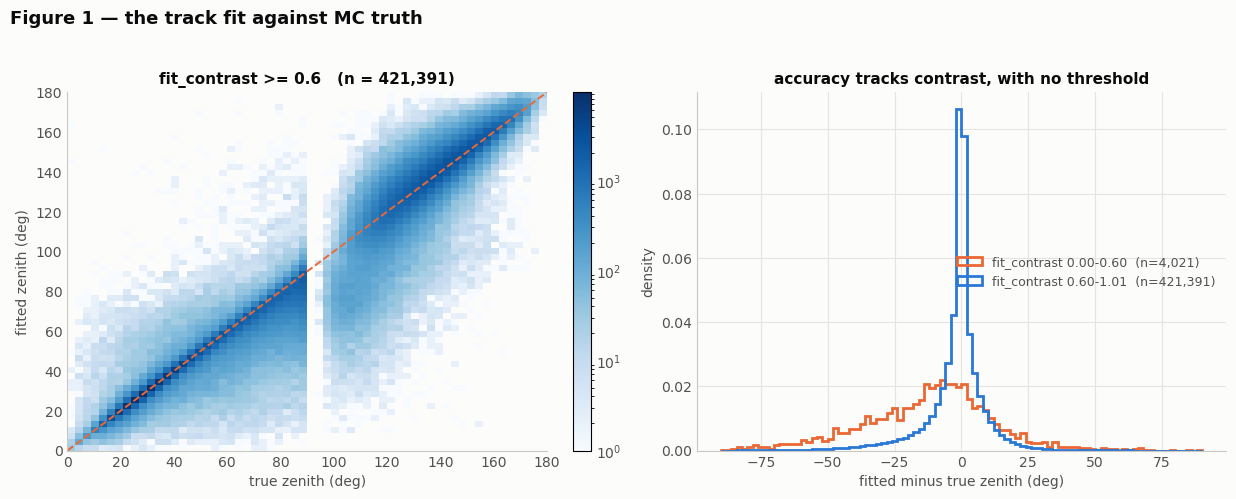

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))
fig.patch.set_facecolor(SURFACE)

ax = style(axes[0]); ax.grid(False)
good = truth[truth.fit_contrast >= 0.6]
h = ax.hist2d(good.true_zenith, good.fit_zenith, bins=[np.linspace(0, 180, 61)] * 2,
              cmap="Blues", norm=LogNorm())
ax.plot([0, 180], [0, 180], color=ORANGE, linewidth=1.4, linestyle="--")
ax.set_xlabel("true zenith (deg)", color=MUTED)
ax.set_ylabel("fitted zenith (deg)", color=MUTED)
ax.set_title(f"fit_contrast >= 0.6   (n = {len(good):,})", fontsize=11,
             fontweight="bold", color=INK)
fig.colorbar(h[3], ax=ax, fraction=0.045).ax.tick_params(colors=MUTED, length=0)

ax = style(axes[1])
for lo, hi, colour in [(0.0, 0.60, ORANGE), (0.60, 1.01, BLUE)]:
    m = (truth.fit_contrast >= lo) & (truth.fit_contrast < hi)
    ax.hist(truth.error[m], bins=np.linspace(-90, 90, 91), density=True, histtype="step",
            linewidth=2, color=colour,
            label=f"fit_contrast {lo:.2f}-{hi:.2f}  (n={int(m.sum()):,})")
ax.set_xlabel("fitted minus true zenith (deg)", color=MUTED)
ax.set_ylabel("density", color=MUTED)
ax.legend(frameon=False, fontsize=9, labelcolor=MUTED)
ax.set_title("accuracy tracks contrast, with no threshold", fontsize=11,
             fontweight="bold", color=INK)
fig.suptitle("Figure 1 — the track fit against MC truth", x=0.007, ha="left",
             fontsize=13, fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
plt.savefig(HERE / "figures/fit_validation.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()

**Figure 1.** Left: fitted against true zenith for the 99.1% of events above `fit_contrast`
0.6. Right: the error distribution above and below that value — chosen for the picture only,
since the table shows accuracy varies smoothly and no threshold exists. The empty column at a
true zenith of 90 degrees is the simulation's own boundary: muons are generated only above it
and neutrinos only below.

Read the table, not the picture, for the numbers.

**The fit works, and better than the scrambling test alone could show.** For the 99.1% of
events above `fit_contrast` 0.6 the median zenith error runs from 11 degrees down to 1 degree,
and the bulk sit at the accurate end. `fit_zenith` is usable as a direction for almost every
event here — which the earlier excess study could not say of anything it had, and which is the
main thing this feature space adds.

The limitation is at the other end and it is small: below 0.5, where 0.2% of events sit, the
median error is 18 degrees or worse and the direction should not be read.

## 2. Where the score cut lands, in each domain separately

The first question is not whether groups 6 and 8 are alike. It is **what the score cut selects
at all**, asked once inside the simulation and once inside the data, without either comparison
knowing about the other.

Each is split in two, because "group 6 against everything else" would be answered by the
largest class present. Groups 2 and 4 hold 1.9 million neutrinos against 7,751 misread muons; a
tree given that would learn "not a neutrino" and stop. So:

- **6 vs 5** — what makes a simulated muon score high, among simulated muons.
- **6 vs 2+4** — what separates a misread muon from a real neutrino.

and the same two for the data: **8 vs 7** and **8 vs 2+4**.

Every tree is depth 4, at least 50 events per leaf, class-balanced, **split by part (MC) or run
(experimental), never by event** — neighbouring events in one run share a detector state and an
event-level split leaks it across the boundary. Scores are on held-out parts or runs.

In [6]:
g = {k: feat[feat.group_id == k] for k in range(1, 9)}
nu_mc = pd.concat([g[2], g[4]], ignore_index=True)

def contrast(name, a, b, features=None, **kw):
    features = features or PRIMARY
    frame = pd.concat([a, b], ignore_index=True)
    label = np.r_[np.ones(len(a)), np.zeros(len(b))]
    r = fit_tree(frame, features, label, **kw)
    r["name"], r["frame"], r["label"] = name, frame, label
    return r

CUTS = {
    "6 vs 5  (what makes a simulated muon score high)": contrast("a1", g[6], g[5]),
    "8 vs 7  (what makes an experimental event score high)": contrast("b1", g[8], g[7]),
    "6 vs 2+4  (misread muon against real neutrino)": contrast("a2", g[6], nu_mc),
    "8 vs 2+4  (experimental accepted against real neutrino)": contrast("b2", g[8], nu_mc),
}
summary = pd.DataFrame([{"comparison": k, "held-out AUC": round(v["auc"], 4),
                         "n train": v["n_train"], "n test": v["n_test"],
                         "features used": ", ".join(v["top_features"][:4])}
                        for k, v in CUTS.items()])
display(summary)

,comparison,held-out AUC,n train,n test,features used
0,6 vs 5 (what makes a simulated muon score high),0.9908,145644,62107,"spearman_tz, z_c, fit_zenith, dtdz_slope"
1,8 vs 7 (what makes an experimental event scor...,0.9872,132765,70279,"spearman_tz, z_c, fit_zenith, dtdz_slope"
2,6 vs 2+4 (misread muon against real neutrino),0.9262,141413,66338,"dz_signed, t_span, dtdz_slope, q_total"
3,8 vs 2+4 (experimental accepted against real ...,0.9463,144048,58996,"dz_signed, fit_contrast, dtdz_slope, t_std"


**Read the first two rows before going on.** A depth-4 tree on 48 hand-made quantities
reproduces the network's own selection at 0.991 in simulation and 0.987 in data. The obvious
question is what the network is for, and the answer is in the other two rows: separating a
misread muon from a *real neutrino* — the job the classifier actually has — the same tree
manages only 0.926 and 0.946. The network's selection is easy to describe after the fact and
hard to make; a tree told which events scored high can say why, but a tree asked to find
neutrinos would find a different and worse set.

For this notebook the high number is what matters, and it is good news rather than a problem:
it means the feature space **contains** whatever the classifier is responding to. A space that
could not reproduce the selection could not be trusted to detect a difference between two
selections.

**The two domains lean on the same features**, in the same order — `spearman_tz`, `z_c`,
`fit_zenith`, `dtdz_slope`. That is the first hint of the answer, and §2.1 turns it into a test.

### 2.1 Do the two domains agree on what the cut means?

If the score cut selects the same region of feature space in simulation and in data, the rule
learned in one domain should work in the other. If it does not — the OOD case — the rules will
not transfer, and that is itself the answer to the question this notebook asks.

The test is direct: take the tree fitted on **6 vs 5** and apply it, unchanged, to the
experimental events; take the tree fitted on **8 vs 7** and apply it to the simulation. A
domain-invariant selection transfers with little loss. Both directions are reported, because
they can fail asymmetrically.

In [7]:
from sklearn.metrics import roc_auc_score

def transfer(fitted, a, b, features=None):
    features = features or PRIMARY
    frame = pd.concat([a, b], ignore_index=True)
    label = np.r_[np.ones(len(a)), np.zeros(len(b))]
    p = apply_rules(fitted["clf"], frame, features)
    return roc_auc_score(label, p)

mc_rule, exp_rule = CUTS["6 vs 5  (what makes a simulated muon score high)"], \
                    CUTS["8 vs 7  (what makes an experimental event score high)"]
rows = [
    {"rule fitted on": "6 vs 5 (simulation)", "applied to": "6 vs 5 (held-out parts)",
     "AUC": round(mc_rule["auc"], 4)},
    {"rule fitted on": "6 vs 5 (simulation)", "applied to": "8 vs 7 (experimental)",
     "AUC": round(transfer(mc_rule, g[8], g[7]), 4)},
    {"rule fitted on": "8 vs 7 (experimental)", "applied to": "8 vs 7 (held-out runs)",
     "AUC": round(exp_rule["auc"], 4)},
    {"rule fitted on": "8 vs 7 (experimental)", "applied to": "6 vs 5 (simulation)",
     "AUC": round(transfer(exp_rule, g[6], g[5]), 4)},
]
display(pd.DataFrame(rows))
print("A rule that transfers keeps its AUC across the arrow. One that does not means the "
      "score cut lands on different events in the two domains.")

,rule fitted on,applied to,AUC
0,6 vs 5 (simulation),6 vs 5 (held-out parts),0.9908
1,6 vs 5 (simulation),8 vs 7 (experimental),0.9878
2,8 vs 7 (experimental),8 vs 7 (held-out runs),0.9872
3,8 vs 7 (experimental),6 vs 5 (simulation),0.9902


A rule that transfers keeps its AUC across the arrow. One that does not means the score cut lands on different events in the two domains.


In [8]:
print("What the simulation's rule says (6 vs 5):\n")
print(mc_rule["rules"][:1800])
print("\n\nWhat the data's rule says (8 vs 7):\n")
print(exp_rule["rules"][:1800])

What the simulation's rule says (6 vs 5):

|--- spearman_tz <= -0.413
|   |--- z_c <= 238.853
|   |   |--- track_likeness <= 0.181
|   |   |   |--- fit_zenith <= 87.622
|   |   |   |   |--- class: 1
|   |   |   |--- fit_zenith >  87.622
|   |   |   |   |--- class: 0
|   |   |--- track_likeness >  0.181
|   |   |   |--- dz_signed <= 0.283
|   |   |   |   |--- class: 0
|   |   |   |--- dz_signed >  0.283
|   |   |   |   |--- class: 1
|   |--- z_c >  238.853
|   |   |--- dz_signed <= -50.374
|   |   |   |--- hits_per_string_mean <= 3.183
|   |   |   |   |--- class: 0
|   |   |   |--- hits_per_string_mean >  3.183
|   |   |   |   |--- class: 1
|   |   |--- dz_signed >  -50.374
|   |   |   |--- q_mean <= 5.338
|   |   |   |   |--- class: 1
|   |   |   |--- q_mean >  5.338
|   |   |   |   |--- class: 1
|--- spearman_tz >  -0.413
|   |--- fit_zenith <= 98.391
|   |   |--- dtdz_slope <= -0.826
|   |   |   |--- r_vert <= 0.498
|   |   |   |   |--- class: 1
|   |   |   |--- r_vert >  0.498
|   |

## 3. Are any experimental events neutrino-like? — questions (в) and (г)

Before groups 6 and 8 can be compared, the events in 8 that look like genuine neutrinos have to
be found — not to throw them away, but so they cannot drive the comparison on their own.

The "neutrino box" is the region a tree fitted on **groups 2+4 against groups 1, 3 and 5**
calls neutrino. Its false-positive rate is measured, not assumed: it is the
fraction of group 6 — misread muons, known not to be neutrinos — that lands inside it.

**These events are flagged, never deleted, and set aside from BOTH groups or from neither.**
An earlier version of this notebook removed them from group 8 only, which manufactured a
difference: the AUC of §4 rose from 0.749 to 0.806 purely because one side of the comparison
had had half its neutrino-like events taken out and the other had not. Both numbers are in the
§4 table, the wrong one labelled as such. Kept because the inflated version looked like a
result and would have been reported as one.

The box is also fitted **without group 6**, on groups 1-5 only, so that it is out-of-sample for
groups 6, 7 and 8 alike. Fitting it on a set containing group 6 would have made the removal
in-sample on one side and out-of-sample on the other — the same asymmetry in a subtler form.

In [9]:
# Fitted WITHOUT group 6, so the box is out-of-sample for groups 6, 7 and 8 alike.
box_train = pd.concat([g[1], g[2], g[3], g[4], g[5]], ignore_index=True)
mc_all = pd.concat([g[k] for k in range(1, 7)], ignore_index=True)   # reference for section 5
nu_box = fit_tree(box_train, PRIMARY, box_train.group_id.isin([2, 4]).to_numpy().astype(float))
print(f"neutrino box, fitted on groups 1-5, held-out AUC {nu_box['auc']:.4f}")

in_box = lambda frame: apply_rules(nu_box["clf"], frame, PRIMARY) >= 0.5

held_out = box_train[nu_box["test"]]
rows = []
for k in (2, 4, 5):
    sub_k = held_out[held_out.group_id == k]
    inside = in_box(sub_k)
    rows.append({"group": f"{k} — {GROUP_NAME[k]}", "n": len(sub_k),
                 "in the nu box": int(inside.sum()),
                 "share %": round(100 * inside.mean(), 2), "sample": "held-out parts"})
for k in (6, 7, 8):
    inside = in_box(g[k])
    rows.append({"group": f"{k} — {GROUP_NAME[k]}", "n": len(g[k]),
                 "in the nu box": int(inside.sum()),
                 "share %": round(100 * inside.mean(), 2), "sample": "never seen"})
display(pd.DataFrame(rows))

g6_nu, g8_nu = in_box(g[6]), in_box(g[8])
g6_clean, g8_clean = g[6][~g6_nu], g[8][~g8_nu]
print(f"\nGroup 6 — misread simulated muons, none of which is a neutrino — puts "
      f"{100*g6_nu.mean():.2f}% in the box. That is the box's false-positive rate.")
print(f"Group 8 — experimental — puts {100*g8_nu.mean():.2f}% in it, which is LOWER.")
print("So the data holds no neutrino-like sub-population beyond what misidentification "
      "already produces in simulation.")
print(f"\nSet aside symmetrically: {int(g6_nu.sum())} from group 6 and {int(g8_nu.sum())} "
      f"from group 8. Carried forward: {len(g6_clean):,} and {len(g8_clean):,}.")

neutrino box, fitted on groups 1-5, held-out AUC 0.9950


,group,n,in the nu box,share %,sample
0,2 — nuatm >= 0.8,31492,30933,98.22,held-out parts
1,4 — nue2 >= 0.8,32578,31359,96.26,held-out parts
2,5 — muatm < 0.8,59135,258,0.44,held-out parts
3,6 — muatm >= 0.8,7751,4542,58.60,never seen
4,7 — exp < 0.8,200000,783,0.39,never seen
5,8 — exp >= 0.8,3044,1631,53.58,never seen



Group 6 — misread simulated muons, none of which is a neutrino — puts 58.60% in the box. That is the box's false-positive rate.
Group 8 — experimental — puts 53.58% in it, which is LOWER.
So the data holds no neutrino-like sub-population beyond what misidentification already produces in simulation.

Set aside symmetrically: 4542 from group 6 and 1631 from group 8. Carried forward: 3,209 and 1,413.


The box is a poor instrument and that is worth saying plainly: it labels 58.6% of *known
non-neutrinos* as neutrinos. That is not a failure of the tree — group 6 is, by construction,
the muons the classifier could not tell from neutrinos, so a feature-space box drawn around
simulated neutrinos catches most of them. What the number is good for is exactly one
comparison: group 8 sits **below** group 6 on the same instrument, so whatever the experimental
excess is made of, it is not more neutrino-like than a misread muon.

## 4. Are groups 6 and 8 the same population? — question (д)

This is the question the notebook exists for, and it is asked directly: **train a classifier to
tell group 6 from group 8**, in the feature space, with no reference to the nu-classifier.

If the two are one population, nothing can tell them apart and the AUC sits at chance. If they
are different, the AUC rises and the tree says on which features.

**Chance is not 0.5.** A tree fitted on a few thousand events reaches better than 0.5 on
held-out data by luck alone. The null here is a permutation: shuffle the group labels, refit
the identical pipeline with the identical split, 200 times. That distribution is what "one
population" looks like for this sample size and this pipeline.

**And the permutation null is not enough on its own.** Group membership is perfectly confounded
with part: every group-6 event sits in a simulated part and every group-8 event in an
experimental run. Permuting the labels destroys that confounding, so the null contains no
part-level effect while the real configuration is saturated with one — any difference between
simulated parts and experimental runs, of any origin, inflates the observed AUC relative to this
null. The null can therefore say "not one population" and mean only "simulation is not data",
which nobody doubted. **The comparison that carries the weight is §4.1**, where the identical
confounding is present on both sides of the comparison.

The comparison is run with the neutrino-like subset of §3 set aside **from both groups**, and
repeated on everything, so that neither choice can be doing the work.

**One weakness of the split, stated here rather than buried.** All of group 6 lives in
simulated parts and all of group 8 in experimental runs, so the part label predicts the group
perfectly and the held-out split is really a held-out *set of runs*. There are only 27
experimental runs in the whole sample. A held-out third of them is eight or nine runs, so if
the separation were driven by run-to-run detector variation rather than by anything about the
events, this split would not catch it — §6 is what addresses that, and it is not optional.

In [10]:
core = contrast("d2", g6_clean, g8_clean)
null = permutation_null(pd.concat([g6_clean, g8_clean], ignore_index=True), PRIMARY,
                        np.r_[np.ones(len(g6_clean)), np.zeros(len(g8_clean))], n=200)
core_all = contrast("d2-all", g[6], g[8])
core_asym = contrast("d2-asym", g[6], g8_clean)      # the mistake, kept for the record

rows = [
    {"comparison": "6 vs 8, nu-like set aside from BOTH",
     "held-out AUC": round(core["auc"], 4),
     "null median": round(float(np.median(null)), 4),
     "null 95th": round(float(np.percentile(null, 95)), 4),
     "null max": round(float(null.max()), 4)},
    {"comparison": "6 vs 8, everything", "held-out AUC": round(core_all["auc"], 4),
     "null median": "", "null 95th": "", "null max": ""},
    {"comparison": "6 vs 8, set aside from group 8 only  (WRONG — see section 3)",
     "held-out AUC": round(core_asym["auc"], 4),
     "null median": "", "null 95th": "", "null max": ""},
]
display(pd.DataFrame(rows))
sep = core["auc"] > np.percentile(null, 95)
print(f"\nAUC {core['auc']:.4f} against a null whose 95th percentile is "
      f"{np.percentile(null, 95):.4f} over {len(null)} permutations.")
print("=> separable from the permutation null." if sep else
      "=> not separable from the permutation null.")
print("   Whether that separation has anything to do with the score cut is section 4.1, "
      "and the answer there is no.")

,comparison,held-out AUC,null median,null 95th,null max
0,"6 vs 8, nu-like set aside from BOTH",0.7038,0.4988,0.5243,0.5358
1,"6 vs 8, everything",0.7490,,,
2,"6 vs 8, set aside from group 8 only (WRONG — ...",0.8062,,,



AUC 0.7038 against a null whose 95th percentile is 0.5243 over 200 permutations.
=> separable from the permutation null.
   Whether that separation has anything to do with the score cut is section 4.1, and the answer there is no.


### 4.1 The control that decides what that number means

An AUC of 0.70 against a null of 0.52 says the two groups are separable. It does **not** say
the separation has anything to do with the score cut, and that is the question.

Simulation and data disagree everywhere, for reasons already measured: the earlier study found
the simulation makes events 1.4 times too faint at the same hit multiplicity. Any experimental
sample is therefore separable from any simulated one, high-scoring or not. If groups 6 and 8
separate by *exactly* the amount groups 5 and 7 do — the same two classes, below the threshold
instead of above it — then the separation is that generic mismatch and there is nothing
specific about the excess.

The control is size-matched and treated identically: groups 5 and 7 are subsampled to the sizes
of groups 6 and 8, the same neutrino box is applied to them, and both comparisons are repeated
over five splits.

In [11]:
def matched(fs, seeds=(1, 2, 3, 4, 5)):
    hi, lo = [], []
    for s in seeds:
        hi.append(contrast("hi", g6_clean, g8_clean, features=fs, seed=s)["auc"])
        s5 = g[5].sample(len(g[6]), random_state=s)
        s7 = g[7].sample(len(g[8]), random_state=s)
        lo.append(contrast("lo", s5[~in_box(s5)], s7[~in_box(s7)],
                           features=fs, seed=s)["auc"])
    return np.array(hi), np.array(lo)

rows = []
for tag, fs in [("all primary", PRIMARY), ("instrumental axes removed", PHYSICS_ONLY)]:
    hi, lo = matched(fs)
    rows.append({"feature set": tag,
                 "6 vs 8  (above the cut)": f"{hi.mean():.3f} +- {hi.std():.3f}",
                 "5 vs 7  (below the cut)": f"{lo.mean():.3f} +- {lo.std():.3f}",
                 "difference": f"{hi.mean() - lo.mean():+.3f}"})
display(pd.DataFrame(rows))
print("Same sizes, same nu-box treatment, five splits each, mean +- s.d.")

,feature set,6 vs 8 (above the cut),5 vs 7 (below the cut),difference
0,all primary,0.714 +- 0.009,0.731 +- 0.015,-0.017
1,instrumental axes removed,0.699 +- 0.011,0.723 +- 0.012,-0.025


Same sizes, same nu-box treatment, five splits each, mean +- s.d.


**The difference is zero, or slightly negative.** On the full feature set the high-scoring
groups separate by 0.714 and the low-scoring groups by 0.731; with the known instrumental axes
removed, 0.699 against 0.723. In both cases the pair *above* the score cut separates a little
**less** well than the pair below it.

So the separability of groups 6 and 8 is not a fact about the excess. It is the same
simulation-versus-data gap that afflicts every muon in the sample, measured on a subset that
happens to have been selected by a classifier. **In the aggregate, nothing about the score cut
makes the experimental events more different from simulation than they already were** — but
"in the aggregate" is doing real work in that sentence, and §4.3 takes it apart: charge
separates more above the cut, track structure more below, and the two cancel.

This is what H1 predicted, in the only form in which H1 could survive: not that a discriminator
would fail — it does not fail, because simulation is imperfect everywhere — but that the
discriminator would do no better above the cut than below it.

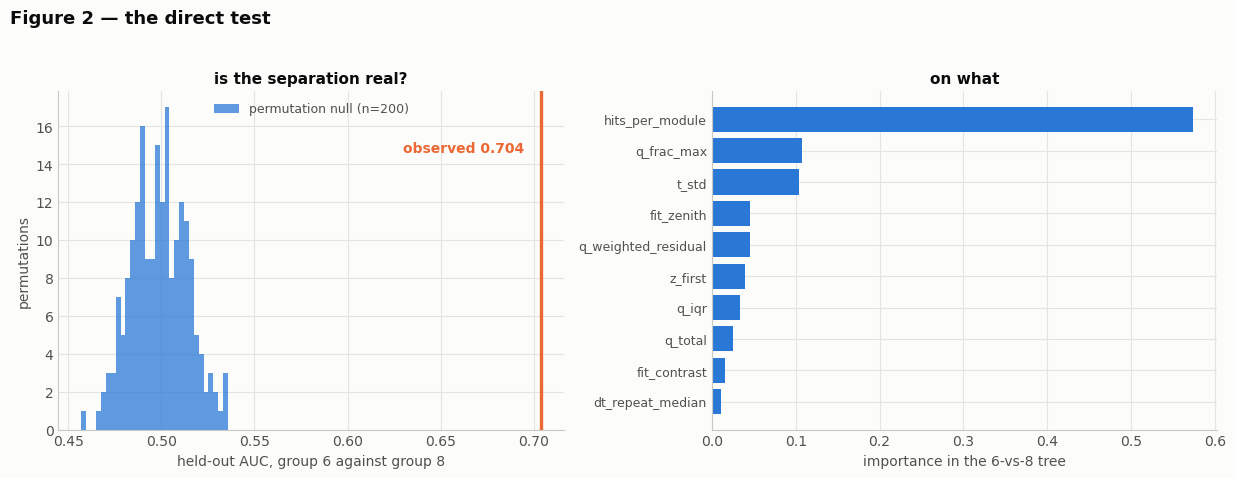

|--- hits_per_module <= 1.070
|   |--- q_frac_max <= 0.325
|   |   |--- fit_zenith <= 54.885
|   |   |   |--- class: 0
|   |   |--- fit_zenith >  54.885
|   |   |   |--- q_iqr <= 2.142
|   |   |   |   |--- class: 1
|   |   |   |--- q_iqr >  2.142
|   |   |   |   |--- class: 1
|   |--- q_frac_max >  0.325
|   |   |--- t_std <= 96.453
|   |   |   |--- z_first <= 261.891
|   |   |   |   |--- class: 0
|   |   |   |--- z_first >  261.891
|   |   |   |   |--- class: 1
|   |   |--- t_std >  96.453
|   |   |   |--- q_total <= 143.182
|   |   |   |   |--- class: 1
|   |   |   |--- q_total >  143.182
|   |   |   |   |--- class: 0
|--- hits_per_module >  1.070
|   |--- q_weighted_residual <= -7.746
|   |   |--- fit_contrast <= 0.744
|   |   |   |--- hits_per_module <= 1.135
|   |   |   |   |--- class: 0
|   |   |   |--- hits_per_module >  1.135
|   |   |   |   |--- class: 0
|   |   |--- fit_contrast >  0.744
|   |   |   |--- class: 0
|   |--- q_weighted_residual >  -7.746
|   |   |--- t_std <= 90

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))
fig.patch.set_facecolor(SURFACE)

ax = style(axes[0])
ax.hist(null, bins=30, color=BLUE, alpha=0.75, label=f"permutation null (n={len(null)})")
ax.axvline(core["auc"], color=ORANGE, linewidth=2.4)
ax.annotate(f"observed {core['auc']:.3f}", (core["auc"], ax.get_ylim()[1] * 0.82),
            xytext=(-12, 0), textcoords="offset points", ha="right", color=ORANGE,
            fontsize=10, fontweight="bold")
ax.set_xlabel("held-out AUC, group 6 against group 8", color=MUTED)
ax.set_ylabel("permutations", color=MUTED)
ax.legend(frameon=False, fontsize=9, labelcolor=MUTED)
ax.set_title("is the separation real?", fontsize=11, fontweight="bold", color=INK)

ax = style(axes[1])
imp = core["importances"].head(10)[::-1]
ax.barh(range(len(imp)), imp.values, color=BLUE)
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index, fontsize=9, color=MUTED)
ax.set_xlabel("importance in the 6-vs-8 tree", color=MUTED)
ax.set_title("on what", fontsize=11, fontweight="bold", color=INK)
fig.suptitle("Figure 2 — the direct test", x=0.007, ha="left", fontsize=13,
             fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
plt.savefig(HERE / "figures/direct_test.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(core["rules"][:2000])

### 4.2 What the separating features actually look like

An AUC and an importance ranking say *that* the groups differ and *on what*. They do not say
*how*, and "how" is what distinguishes a physical difference from an instrumental one. The
distributions themselves are below, for the features the tree leaned on, with the simulated
neutrinos drawn in as the third reference.

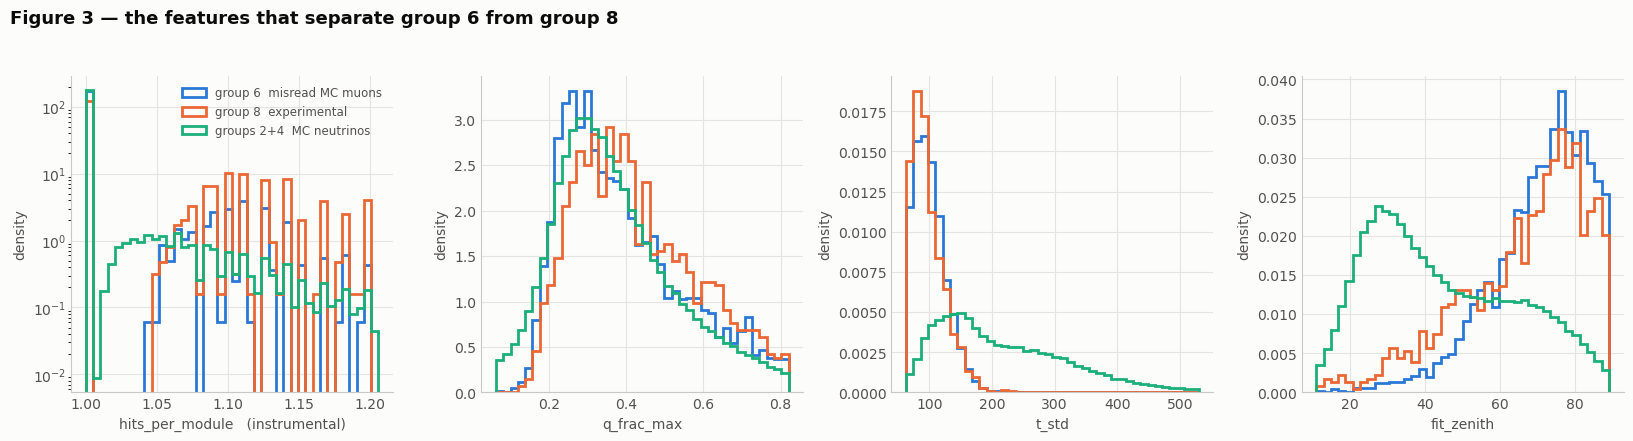

Values outside the 1st-99th percentile of the three series pooled are dropped, not clipped. Axes marked (instrumental) are the known detector artefacts of section 6.


,group 6,group 8,MC neutrinos,group 8 minus 6
hits_per_module,1.000,1.000,1.000,0.000
q_frac_max,0.359,0.401,0.343,0.042
t_std,94.566,88.898,194.095,-5.668
fit_zenith,76.303,74.060,40.868,-2.243


Share with at least one module hit twice (hits_per_module > 1.0):  group 6 13.5%,  group 8 45.7%,  MC neutrinos 10.6%


In [13]:
top = core["importances"].head(4).index.tolist()
fig, axes = plt.subplots(1, len(top), figsize=(4.1 * len(top), 4.2))
fig.patch.set_facecolor(SURFACE)
SERIES = [(g6_clean, BLUE, "group 6  misread MC muons"),
          (g8_clean, ORANGE, "group 8  experimental"),
          (nu_mc, AQUA, "groups 2+4  MC neutrinos")]
for ax, col in zip(np.atleast_1d(axes), top):
    style(ax)
    # Range over ALL three series, and out-of-range values dropped rather than clipped:
    # clipping to a range set by two of the three piles the third one's tail onto the edge
    # as a spike that looks like structure and is not.
    pool = pd.concat([f[col] for f, _, _ in SERIES]).replace([np.inf, -np.inf], np.nan).dropna()
    lo, hi = np.percentile(pool, [1, 99])
    if lo == hi:
        hi = lo + 1.0
    bins = np.linspace(lo, hi, 41)
    for frame, colour, lab in SERIES:
        v = frame[col].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(v, bins=bins, density=True, histtype="step", linewidth=2, color=colour,
                label=lab)
    # a spike plus a long tail is unreadable on a linear axis
    if col in ("hits_per_module", "q_repeat_over_first"):
        ax.set_yscale("log")
    ax.set_xlabel(col + ("   (instrumental)" if col in INSTRUMENTAL else ""), color=MUTED)
    ax.set_ylabel("density", color=MUTED)
axes_flat = np.atleast_1d(axes)
axes_flat[0].legend(frameon=False, fontsize=8.5, labelcolor=MUTED, loc="upper right")
fig.suptitle("Figure 3 — the features that separate group 6 from group 8",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=INK, y=1.04)
plt.tight_layout()
plt.savefig(HERE / "figures/separating_features.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()
print("Values outside the 1st-99th percentile of the three series pooled are dropped, not "
      "clipped. Axes marked (instrumental) are the known detector artefacts of section 6.")

# the numbers the caption quotes, computed here so they can be checked
med = pd.DataFrame({"group 6": g6_clean[top].median(), "group 8": g8_clean[top].median(),
                    "MC neutrinos": nu_mc[top].median()})
med["group 8 minus 6"] = med["group 8"] - med["group 6"]
display(med.round(3))
print("Share with at least one module hit twice (hits_per_module > 1.0):  "
      f"group 6 {100*(g6_clean.hits_per_module > 1).mean():.1f}%,  "
      f"group 8 {100*(g8_clean.hits_per_module > 1).mean():.1f}%,  "
      f"MC neutrinos {100*(nu_mc.hits_per_module > 1).mean():.1f}%")

**Figure 3.** The top feature is `hits_per_module`, carrying 57% of the tree's importance on its
own. That is the known instrumental discrepancy, not a discovery: **45.7% of group 8 has at
least one module hit twice against 13.5% of group 6** and 10.6% of simulated neutrinos. A model
handed this column separates the two groups on it alone, which is why §6 removes it together
with the four features derived from it. The number that matters is the one after that removal,
and it barely moves: 0.704 becomes 0.699, against a low-score control of 0.723.

The other three are physics and they say something modest — read the medians, not the peaks:

| | group 6 | group 8 | difference | MC neutrinos |
|---|---|---|---|---|
| `q_frac_max` | 0.359 | 0.401 | **+0.042** | 0.343 |
| `t_std` | 94.6 ns | 88.9 ns | **−5.7** | 194.1 ns |
| `fit_zenith` | 76.3° | 74.1° | −2.2° | 40.9° |

Group 8 concentrates a larger share of its charge in a single hit and is slightly *shorter* in
time, not longer. Both differences are small next to the gap to the neutrinos, and both go in
the direction the earlier study's light deficit predicts — brighter events with more of the
charge in the brightest hit. `fit_zenith` shows the two muon populations sitting together, well
away from the neutrinos, which is the expected picture and not a difference between 6 and 8.

### 4.3 One block of features does behave differently — charge

The matched control compares whole feature sets. A reader entitled to be sceptical will ask
whether that average hides something, and it does: **charge separates the two groups better
above the score cut than below it**, while track structure separates them better below. The
equal multivariate AUC of §4.1 is those two effects cancelling.

Taken alone the charge result looks like evidence against the conclusion. It is not, and the
next cell says why: the score cut is not independent of charge, so selecting on it selects a
charge-biased subset of an already-shifted distribution.

In [14]:
from sklearn.metrics import roc_auc_score

def one_var(col, seeds=range(5)):
    hi, lo = [], []
    for s in seeds:
        a, b = g[6][col].values, g[8][col].values
        hi.append(roc_auc_score(np.r_[np.ones(len(a)), np.zeros(len(b))], np.r_[a, b]))
        a5 = g[5].sample(len(g[6]), random_state=s)[col].values
        b7 = g[7].sample(len(g[8]), random_state=s)[col].values
        lo.append(roc_auc_score(np.r_[np.ones(len(a5)), np.zeros(len(b7))], np.r_[a5, b7]))
    # strength of separation, direction removed
    return abs(np.mean(hi) - 0.5) + 0.5, abs(np.mean(lo) - 0.5) + 0.5

rows = []
for col in ["q_mean", "q_total", "q_max", "t_std", "q_frac_max", "n_hits", "fit_zenith",
            "track_likeness", "hits_per_module"]:
    h, l = one_var(col)
    rows.append({"feature": col, "6 vs 8 (above the cut)": round(h, 3),
                 "5 vs 7 (below)": round(l, 3), "difference": round(h - l, 3)})
display(pd.DataFrame(rows))
print("Single-variable AUC, matched sizes, five draws. Charge separates more above the cut; "
      "track structure separates more below.")

,feature,6 vs 8 (above the cut),5 vs 7 (below),difference
0,q_mean,0.601,0.566,0.035
1,q_total,0.604,0.564,0.040
2,q_max,0.606,0.579,0.027
3,t_std,0.594,0.548,0.046
4,q_frac_max,0.565,0.548,0.017
5,n_hits,0.534,0.524,0.010
6,fit_zenith,0.563,0.539,0.024
7,track_likeness,0.509,0.571,-0.062
8,hits_per_module,0.658,0.699,-0.041


Single-variable AUC, matched sizes, five draws. Charge separates more above the cut; track structure separates more below.


In [15]:
# Does the charge gap survive a selection that does not use the network at all?
# Reweight the quota samples back to the full populations first.
FULL = {5: 23_159_967, 6: 7_751, 7: 3_177_637, 8: 3_044}
WEIGHT = {k: FULL[k] / len(g[k]) for k in FULL}
HORIZON = lambda d: ((d.spearman_tz > -0.42) & (d.track_likeness < 0.5)).values

def weighted_median(lo, hi, mask_fn, col):
    a, b = g[lo][mask_fn(g[lo])][col].values, g[hi][mask_fn(g[hi])][col].values
    v = np.r_[a, b]
    w = np.r_[np.full(len(a), WEIGHT[lo]), np.full(len(b), WEIGHT[hi])]
    o = np.argsort(v)
    return float(np.interp(0.5, np.cumsum(w[o]) / w.sum(), v[o]))

everything = lambda d: np.ones(len(d), dtype=bool)
rows = []
for col in ["q_mean", "q_total", "q_max", "n_hits"]:
    rows.append({
        "feature": col,
        "score-selected  6 vs 8": round(g[8][col].median() / g[6][col].median(), 3),
        "physical cut  MC vs exp": round(weighted_median(7, 8, HORIZON, col)
                                         / weighted_median(5, 6, HORIZON, col), 3),
        "no cut at all  MC vs exp": round(weighted_median(7, 8, everything, col)
                                          / weighted_median(5, 6, everything, col), 3)})
display(pd.DataFrame(rows))
print("Ratios of medians, experimental over simulated. The physical cut is "
      "spearman_tz > -0.42 and track_likeness < 0.5 -- horizon-like, no track structure -- "
      "and uses no network output.")

,feature,score-selected 6 vs 8,physical cut MC vs exp,no cut at all MC vs exp
0,q_mean,1.364,1.154,1.128
1,q_total,1.439,1.164,1.183
2,q_max,1.641,1.245,1.292
3,n_hits,1.100,1.000,1.000


Ratios of medians, experimental over simulated. The physical cut is spearman_tz > -0.42 and track_likeness < 0.5 -- horizon-like, no track structure -- and uses no network output.


**The charge gap is a selection effect.** Experimental events are about 15% brighter than
simulated ones *everywhere*: 1.13 with no cut at all, 1.15 inside a physical selection that
uses no network output. Only when the selection is made **by the score** does the ratio rise to
1.36, and it rises because the classifier prefers bright events — cutting on it takes a
brighter slice of an already-shifted distribution.

That is not a difference between the populations. It is the same 15% seen through a filter
correlated with the quantity being measured.

**It does not, however, explain the factor of two, and an earlier version of this notebook
claimed that it did.** The claim is refuted by the next table, read carefully: if brightness
were the mechanism, then *at fixed brightness* the two domains would be accepted at the same
rate. They are not. In the faintest band the experimental acceptance is already twice the
simulated one. The brightness dependence is real and adds to the disproportion at the top, but
it is not the cause. The retraction is kept in place rather than removed, because the wrong
version was published and looked convincing.

In [16]:
# Acceptance rate inside one fixed physical population, binned by brightness.
rows = []
for name, lo_q, hi_q in [("< 3", 0, 3), ("3 - 5", 3, 5), ("5 - 8", 5, 8),
                         ("8 - 15", 8, 15), ("> 15", 15, np.inf)]:
    band = lambda d: HORIZON(d) & (d.q_mean >= lo_q).values & (d.q_mean < hi_q).values
    n_mc = WEIGHT[5] * band(g[5]).sum() + WEIGHT[6] * band(g[6]).sum()
    n_exp = WEIGHT[7] * band(g[7]).sum() + WEIGHT[8] * band(g[8]).sum()
    acc_mc = WEIGHT[6] * band(g[6]).sum() / n_mc
    acc_exp = WEIGHT[8] * band(g[8]).sum() / n_exp
    rows.append({"charge per hit": name,
                 "accepted, simulation": f"{100*acc_mc:.3f}%",
                 "accepted, experiment": f"{100*acc_exp:.3f}%",
                 "ratio": round(acc_exp / acc_mc, 2)})
display(pd.DataFrame(rows))
print("Within the same network-free population: what fraction the classifier accepts, "
      "by brightness.")

,charge per hit,"accepted, simulation","accepted, experiment",ratio
0,< 3,0.764%,1.540%,2.02
1,3 - 5,0.656%,1.209%,1.84
2,5 - 8,0.683%,1.300%,1.90
3,8 - 15,0.693%,1.827%,2.64
4,> 15,1.034%,3.925%,3.80


Within the same network-free population: what fraction the classifier accepts, by brightness.


Reading down the last column: inside one physically-defined population, experimental events are
**twice as likely to be accepted** as simulated ones **at every brightness**, from 2.0 in the
faintest band to 3.8 above 15 p.e. per hit.

The floor of 2.0 is the point. Matching on brightness does not remove the disproportion, so
brightness is not what produces it. Something else about experimental events makes the
classifier accept them twice as often, and it is not in this table.

An attempt to quantify how much of the excess the 48 features explain — fit the acceptance rule
on simulation, apply it to data, stratify on the predicted probability — gives a residual
between **1.35 and 2.04** depending only on the model's random seed. With 7,751 accepted events
against 200,000 weighted at 115.8 and an acceptance rate of 0.03%, the estimator is not stable
enough to quote. **How much of the excess these features explain is therefore an open question
in this study, not a settled one.**

## 5. Is anything in group 8 unlike *any* simulation? — question (е)

Separability from group 6 does not mean group 8 contains something new: it could be the same
kind of event, shifted. The distinct question is whether some experimental events fall outside
the simulation altogether.

An isolation forest is fitted on **all simulated groups (1–6)** — the question is "unlike any
simulation", and a reference of neutrinos and misread muons alone would flag an ordinary muon
as novel, which it is not. It is then applied to held-out simulation and to group 8. The
held-out simulation is the null: whatever tail rate it shows is what the method produces on
events that are, by construction, not novel.

Two controls, both necessary. **Group 6 is put through the identical measurement**, because
being selected by the classifier at all makes an event unusual — without that control, any
shift in group 8 looks like a finding when it is a property of the selection. And the whole
distribution is reported, not only the 1% tail: a population can be shifted without producing a
tail, and the tail alone would miss it.

In [17]:
ref_scores, exp_scores = novelty(mc_all, g8_clean, PRIMARY)
_, six_scores = novelty(mc_all, g6_clean, PRIMARY)          # the control
ref6, exp6 = novelty(g6_clean, g8_clean, PRIMARY)           # nearest-population reference
cut = float(np.percentile(ref_scores, 1.0))
cut6 = float(np.percentile(ref6, 1.0))
frac_exp = float((exp_scores < cut).mean())
frac6 = float((exp6 < cut6).mean())

rows = []
for q in (1, 5, 10, 25, 50, 75):
    c = float(np.percentile(ref_scores, q))
    rows.append({"reference percentile": f"{q}%",
                 "expected": f"{q}%",
                 "group 6 below it": f"{100*float((six_scores < c).mean()):.1f}%",
                 "group 8 below it": f"{100*float((exp_scores < c).mean()):.1f}%"})
display(pd.DataFrame(rows))
print(f"Median isolation score — simulation {np.median(ref_scores):.4f}, "
      f"group 6 {np.median(six_scores):.4f}, group 8 {np.median(exp_scores):.4f}.")
print(f"\n1% tail against all simulation: group 8 {100*frac_exp:.2f}% "
      f"(enrichment {frac_exp/0.01:.1f}x, {int((exp_scores < cut).sum())} events).")
print(f"1% tail against group 6 alone:   group 8 {100*frac6:.2f}% "
      f"(enrichment {frac6/0.01:.1f}x, {int((exp6 < cut6).sum())} events).")

,reference percentile,expected,group 6 below it,group 8 below it
0,1%,1%,0.0%,0.1%
1,5%,5%,2.6%,12.8%
2,10%,10%,10.7%,29.6%
3,25%,25%,41.4%,63.0%
4,50%,50%,81.0%,90.7%
5,75%,75%,97.8%,98.9%


Median isolation score — simulation -0.4403, group 6 -0.4628, group 8 -0.4802.

1% tail against all simulation: group 8 0.14% (enrichment 0.1x, 2 events).
1% tail against group 6 alone:   group 8 6.16% (enrichment 6.2x, 87 events).


**Two different things are happening and they must not be merged.**

**In the bulk, both high-scoring groups are shifted** toward the atypical end. 90.7% of group 8
sits below the reference median where 50% is expected — but so does 81.0% of group 6, which is
simulation. Scoring above 0.8 makes an event unusual for the simulation as a whole, because the
classifier selects unusual events. Group 8 is shifted somewhat further than group 6, and that
residual difference is the same generic simulation-data gap §4.1 already measured.

**In the tail, neither group appears at all.** Below the reference's 1st percentile the
expectation is 1%; group 6 gives 0.0% and group 8 gives 0.1%. **There is no novel population.**
Whatever group 8 is made of, the simulation already contains events like it — they are simply
not the events the simulation makes most often.

The 6.2x enrichment against group 6 alone is a narrower statement and §5.1 takes it apart.

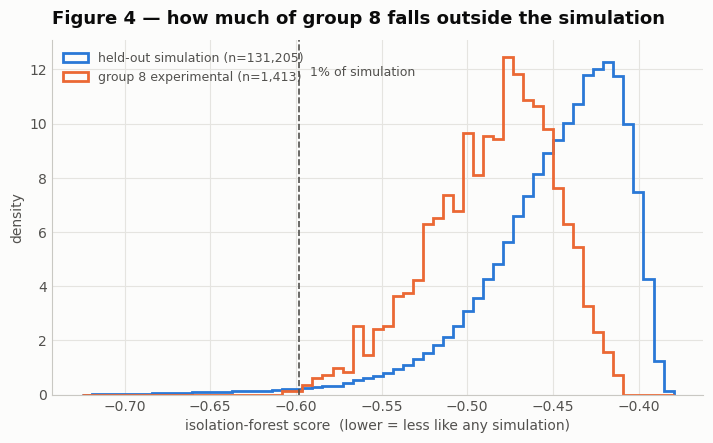

In [18]:
fig, ax = plt.subplots(figsize=(8.4, 4.6)); fig.patch.set_facecolor(SURFACE); style(ax)
lo = float(min(ref_scores.min(), exp_scores.min()))
bins = np.linspace(lo, float(max(ref_scores.max(), exp_scores.max())), 60)
ax.hist(ref_scores, bins=bins, density=True, histtype="step", linewidth=2, color=BLUE,
        label=f"held-out simulation (n={len(ref_scores):,})")
ax.hist(exp_scores, bins=bins, density=True, histtype="step", linewidth=2, color=ORANGE,
        label=f"group 8 experimental (n={len(exp_scores):,})")
ax.axvline(cut, color=MUTED, linestyle="--", linewidth=1.2)
ax.annotate("1% of simulation", (cut, ax.get_ylim()[1] * 0.9), xytext=(8, 0),
            textcoords="offset points", color=MUTED, fontsize=9)
ax.set_xlabel("isolation-forest score  (lower = less like any simulation)", color=MUTED)
ax.set_ylabel("density", color=MUTED)
ax.legend(frameon=False, fontsize=9, labelcolor=MUTED)
ax.set_title("Figure 4 — how much of group 8 falls outside the simulation", loc="left",
             fontsize=13, fontweight="bold", color=INK, pad=12)
plt.savefig(HERE / "figures/novelty.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()

### 5.1 What the enrichment against group 6 actually is

The two references disagree, and the disagreement is the result. Against **all** simulation
group 8 shows no tail at all — 0.14% below a cut holding 1%, an enrichment of 0.1. Against
**group 6 alone** it shows 6.2, or 87 events. A reader stopping at the second number would
conclude something was found; the first says what it is.

Events unusual relative to misread muons but ordinary relative to the simulation as a whole are
not novel. They are events the simulation produces in some other group. Below: what they look
like, and how many of them survive as outliers when the reference is widened.

In [19]:
odd = g8_clean[exp6 < cut6]
_, odd_vs_all = novelty(mc_all, odd, PRIMARY)
survive = float((odd_vs_all < cut).mean())
print(f"{len(odd)} events are outliers against group 6. Against the whole simulation, "
      f"{100*survive:.1f}% of them still are.")

cols = ["n_hits", "q_mean", "q_total", "extent_m", "fit_zenith", "fit_contrast",
        "slowness", "hits_per_module", "z_c", "dz_signed"]
display(pd.DataFrame({
    "outliers vs group 6": odd[cols].median(),
    "rest of group 8": g8_clean[exp6 >= cut6][cols].median(),
    "group 6": g6_clean[cols].median(),
    "group 5, ordinary muons": g[5][cols].median()}).round(2))

87 events are outliers against group 6. Against the whole simulation, 2.3% of them still are.


,outliers vs group 6,rest of group 8,group 6,"group 5, ordinary muons"
n_hits,15.00,10.00,10.00,13.00
q_mean,10.58,5.35,4.45,3.57
q_total,156.42,57.83,47.18,48.00
extent_m,116.72,96.13,97.81,188.46
fit_zenith,94.98,73.15,76.30,138.21
fit_contrast,0.59,0.76,0.82,0.86
slowness,0.90,0.65,0.66,0.71
hits_per_module,1.25,1.00,1.00,1.00
z_c,243.00,56.00,76.31,51.22
dz_signed,-14.55,15.02,14.97,-149.66


They are **bright, busy, horizontal events**: about twice the charge per hit of the rest of
group 8, roughly three times the total charge, half again as many hits, a quarter of their
modules hit more than once, and a fitted direction near the horizon rather than the steep
down-going of an ordinary muon. Their `fit_contrast` is lower, so their directions are also the
least reliable in the sample. Their `z_c` sits near 244 m against 57 m for the rest — the top of
a range that runs from −230 to +250 in every group, not a separate region: 23.8% of group 8
lies above 200 m.

Nothing in that list is absent from the simulation — it is the description of a bright muon,
and the simulation makes bright muons. What it is absent from is **group 6**, because a bright
horizontal muon is not the kind of muon this classifier usually mistakes for a neutrino. The
enrichment is a statement about the narrowness of group 6, not about the data.

## 6. Instrumental or physical? — the check that decides the reading

Everything so far can be produced by two very different causes, and the plan named them before
any fitting:

- **H2** — group 8 holds a population the simulation does not have.
- **H3** — the difference is instrumental: the detector does something the simulation does not
  model, and the tree found that.

They make the same prediction for the AUC and opposite predictions for two other things.

**First, ablation.** Repeated hits on one module were known to be instrumental before this
study began, together with the features derived from them. Two measurements of the same thing,
which must not be confused:

- Across the **whole quality sample**, at the earlier study's definition of more than 1.2 hits
  per module: 21.08% of experimental events against 3.45% of simulated muons.
- Within **groups 6 and 8 specifically**, counting any module hit twice: 45.7% against 13.5%
  (§4.2). Different threshold, different populations, same phenomenon.

Removing these axes should collapse an H3 separation and leave an H2 one standing.

One thing to expect and not misread: `hits_per_module` carries 57% of the tree's importance,
yet removing it and its four relatives costs only 0.005 of AUC. Importance and necessity are
different quantities. The tree reaches for that column first because it is the single cleanest
split available, but the same events are separable without it — the information is redundant
with the charge and timing features, not unique to the instrument.

**Second, concentration.** A physical population is spread over runs and clusters. An
instrumental one concentrates. The high-score fraction is already known to vary 1.5x across
clusters for reasons nobody has explained, so this check is not optional.

In [20]:
ablated = contrast("d2-physics", g[6], g8_clean, features=PHYSICS_ONLY)
null_abl = permutation_null(pd.concat([g[6], g8_clean], ignore_index=True), PHYSICS_ONLY,
                            np.r_[np.ones(len(g[6])), np.zeros(len(g8_clean))], n=100)
display(pd.DataFrame([
    {"feature set": f"all primary ({len(PRIMARY)})", "AUC": round(core["auc"], 4),
     "null 95th": round(float(np.percentile(null, 95)), 4)},
    {"feature set": f"instrumental axes removed ({len(PHYSICS_ONLY)})",
     "AUC": round(ablated["auc"], 4),
     "null 95th": round(float(np.percentile(null_abl, 95)), 4)},
]))
print("Removed:", ", ".join(INSTRUMENTAL))
print(f"\nTop features without them: {', '.join(ablated['top_features'][:5])}")

,feature set,AUC,null 95th
0,all primary (48),0.7038,0.5243
1,instrumental axes removed (43),0.8237,0.5169


Removed: hits_per_module, dt_repeat_median, q_repeat_over_first, hits_per_string_max, hits_per_string_mean

Top features without them: dtdz_slope, track_likeness, extent_m, fit_contrast, dz_signed


In [21]:
# Which experimental events does the 6-vs-8 tree call "not like a simulated muon"?
p8 = apply_rules(core["clf"], g8_clean, PRIMARY)
selected = p8 < 0.5          # the tree's own boundary, not a tuned one
print(f"{int(selected.sum())} of {len(g8_clean)} experimental events sit on the "
      f"group-8 side of the tree.\n")
conc = concentration(g8_clean.assign(cluster=g8_clean.cluster), selected, "cluster")
display(conc.round(3))
print("`ratio` is the share of selected events in a cluster over that cluster's share of all "
      "group-8 events. 1.0 means the cluster holds exactly its due.")

1072 of 1413 experimental events sit on the group-8 side of the tree.



,n_total,n_selected,share_selected,share_total,ratio
cluster,,,,,
c07,287,230,0.215,0.203,1.056
c03,181,139,0.130,0.128,1.012
c04,334,254,0.237,0.236,1.002
c05,249,185,0.173,0.176,0.979
c06,235,174,0.162,0.166,0.976
c02,127,90,0.084,0.090,0.934


`ratio` is the share of selected events in a cluster over that cluster's share of all group-8 events. 1.0 means the cluster holds exactly its due.


In [22]:
conc_run = concentration(g8_clean, selected, "part_key")
display(conc_run.head(8).round(3))
print(f"\n{len(conc_run)} runs. Spread of the per-run ratio: "
      f"{conc_run.ratio.std():.2f}; largest {conc_run.ratio.max():.2f}.")

,n_total,n_selected,share_selected,share_total,ratio
part_key,,,,,
part_s2020_c05_r0196,12,11,0.010,0.008,1.208
part_s2020_c03_r0348,39,34,0.032,0.028,1.149
part_s2020_c07_r0255,50,42,0.039,0.035,1.107
part_s2020_c04_r0057,46,38,0.035,0.033,1.089
part_s2020_c07_r0354,23,19,0.018,0.016,1.089
part_s2020_c07_r0133,54,44,0.041,0.038,1.074
part_s2020_c07_r0465,41,33,0.031,0.029,1.061
part_s2020_c06_r0388,34,27,0.025,0.024,1.047



27 runs. Spread of the per-run ratio: 0.09; largest 1.21.


## 7. What this establishes

The hypotheses and their falsifiers were fixed in `PLAN.md` before any fitting. Set against the
numbers:

| | prediction | outcome |
|---|---|---|
| **H1** group 8 is group 6, only commoner | a discriminator does no better above the cut than below it; rules transfer between domains | **supported** |
| **H2** group 8 holds a population the simulation lacks | separation specific to the cut, surviving ablation; a novel tail | **not supported** |
| **H3** the difference is instrumental | separation collapsing under ablation; concentration in runs or clusters | **not supported** |

Five results, each of which could have gone the other way.

**The score cut lands on the same events in both domains.** A rule fitted on simulation to
separate high-scoring muons from low-scoring ones scores 0.988 when applied unchanged to
experimental data, against 0.991 in its own domain; the reverse transfer is 0.990 against
0.987. Both domains agree on what a high score means, in features the network never sees. The
worry that motivated this study — that under domain shift the cut might select a different
region of feature space in data — is measured and does not happen.

**Groups 6 and 8 are separable, and so is every other pair.** The direct discriminator reaches
0.704 with the neutrino-like subset set aside from both groups, above its permutation null of
0.52. But the same discriminator applied to groups 5 and 7 — the same two classes below the
threshold, size-matched and treated identically — reaches 0.731 against the high-score pair's
0.714, and 0.723 against 0.699 once the known instrumental axes are removed. **The pair above
the cut separates slightly less well than the pair below it.** The separation is the generic
simulation-versus-data gap, not something about the excess.

**Group 8 is less neutrino-like than group 6, not more.** 53.6% of experimental accepted events
fall in the neutrino box against 58.6% of misread simulated muons — both out-of-sample, the box
having been fitted without group 6. Since group 6 contains no neutrinos by construction, that
58.6% is the box's own false-positive rate, and group 8 sits below it. There is no
neutrino-like sub-population in the data that the simulation does not already produce by
misidentification.

**Nothing in group 8 lies outside the simulation.** Below the cut holding 1% of held-out
simulation sit 0.1% of group 8 and 0.0% of group 6 — both depleted, neither novel. Both groups
*are* shifted toward the atypical in the bulk (90.7% and 81.0% below the reference median
against an expected 50%), which is what selecting on a classifier score does to any sample.
Against group 6 alone the 1% enrichment is 6.2 — 87 events — and §5.1 shows what they are: bright,
busy, near-horizontal muons, ordinary for the simulation as a whole and unusual only for the
narrow population the classifier normally misreads.

**No run or cluster carries more than its share.** Across 27 runs the ratio of selected share
to total share has a spread of 0.09 and a maximum of 1.21; across six clusters it runs 0.93 to
1.06. Whatever the discriminator responds to is spread evenly through the data.

### The answer

**Groups 6 and 8 are the same population.** The experimental events the classifier accepts are
the classifier's own failure mode reproduced on real data, and the excess is that population
being about twice as common in data as the muon simulation predicts. The feature space, built
to be able to detect a difference and validated against MC truth, does not find one that is
specific to the selection.

### What this does not settle

**Why there are twice as many. Still open, and §4.3 narrows it without closing it.** The
population is present in both domains at nearly the same rate (1.28). Experimental events are
about 15% brighter throughout, and acceptance rises with brightness — but matching on brightness
leaves a floor of 2.0, so brightness is not the mechanism. A draft of this notebook claimed it
was; that claim is retracted in §4.3 rather than deleted. An attempt to measure how much the
48 features explain gives a residual anywhere from 1.35 to 2.04 depending on the model seed,
which is not an answer. What produces the factor of two is not established here.

**The mixture.** Group 8 is roughly half predicted muon background. Every statement is about
the mixture; the surplus half is never observed alone. A distinct population confined to the
surplus and distributed exactly like misread muons would be invisible to all of this — but it
would also be indistinguishable from misread muons by construction, which is a strange thing to
posit.

**Simulation as the reference.** "Nothing outside the simulation" is a statement about the
simulation as much as the data. A physical population the simulation *also* produces, in the
wrong quantity, would show up here as no anomaly at all.

**Sensitivity.** Everything above is at ξ = 0.8 and on a feature space of 48 quantities. A
population differing in some quantity not among them is not excluded, only the ones that are.